# Stage 5: Synthesis, Model Comparison and Governance

This stage pulls together the Stage 3 recovery and prediction evidence and the Stage 4 stress evidence into one consolidated view, answers the three research questions, and states the governance position and claim boundary. It only reads and combines the saved results, so it runs in seconds.

>  **This notebook is self-contained.** Every result below is computed by the code in this notebook. The heavy cells are checkpointed: with `REGENERATE = False` they reload the saved result files and the notebook opens in a few seconds; set `REGENERATE = True` to rerun the real experiment from scratch. This notebook does not import them: it needs only `credit_dgp.py` and `pipeline_utils.py`.

### 5.1 Build the synthesis

Read every saved result file, recompute the consolidated recovery table (with the signed recovery versus the oracle), and write a single synthesis file plus a one row per model summary table.

In [1]:
import os, json, glob, hashlib, importlib, numpy as np, pandas as pd
OUT = 'outputs'
def load_json(p):
    with open(p) as fh: return json.load(fh)
def save_json(o, p):
    with open(p, 'w') as fh: json.dump(o, fh, indent=2, default=float)

# Load the recovery records, structural fidelity, null thresholds, and the three stress result files.
recov = load_json(f'{OUT}/recovery.json'); R = pd.DataFrame(recov['records']); Pr = pd.DataFrame(recov['predictive'])
strc = pd.DataFrame(load_json(f'{OUT}/structural_fidelity.json'))
null_thr = load_json(f'{OUT}/null_thresholds.json')['threshold_90pct']
stress_forward = load_json(f'{OUT}/stress_forward.json'); stress_fixed = load_json(f'{OUT}/stress_fixed_composition.json')
epi_all = load_json(f'{OUT}/stress_episodes.json'); epi = epi_all['out_of_sample_episodes']; epi_excluded = epi_all['excluded']
TUNED = load_json(f'{OUT}/model_tuning.json')

# Predictive league averaged over every seed and strength (now including calibration slope and average
# precision if Stage 3 saved them).
_pcols = [c for c in ['auc', 'brier', 'ece', 'cal_slope', 'avg_precision'] if c in Pr.columns]
pred_league = Pr.groupby('model')[_pcols].mean().round(4).to_dict('index')
# Consolidated recovery table. Two magnitude views are stored side by side (they answer different
# questions and can disagree, per the critical evaluation): recovery_pct_vs_oracle is the SIGNED MEAN
# coefficient scaling (average-scale, lets over/under-shoot cancel); norm_abs_err_pct is the normalised
# per-pair MEAN ABSOLUTE error over the active pairs (no cancellation, the honest pair-by-pair accuracy).
rec_tbl = {}
for (m, st), g in R[R.strength.isin(['weak', 'moderate', 'strong'])].groupby(['model', 'strength']):
    a = g[g.is_active]; d = g[~g.is_active]
    signed_b = float(a['bhat'].mean()); signed_ob = float(a['oracle_bhat'].mean())
    mean_abs_b = float(a['bhat'].abs().mean()); dc = float(d['bhat'].abs().mean())
    ob_abs = float(a['oracle_bhat'].abs().mean())
    rec_tbl[f'{m}|{st}'] = {'sign_acc': round(float((np.sign(a['bhat']) == np.sign(a['oracle_bhat'])).mean()), 2),
        'mean_b_active': round(mean_abs_b, 3), 'mean_oracle_b_active': round(ob_abs, 3),
        'recovery_pct_vs_oracle': round(100 * signed_b / signed_ob, 1) if abs(signed_ob) > 1e-9 else None,
        'norm_abs_err_pct': round(100 * float((a['bhat'] - a['oracle_bhat']).abs().mean()) / ob_abs, 1) if ob_abs > 0 else None,
        'mean_b_decoy': round(dc, 3), 'active_decoy_ratio': round(mean_abs_b / dc, 2) if dc > 0 else None,
        'power_active': round(float(a['detected'].mean()), 2), 'fpr_decoy': round(float(d['detected'].mean()), 3)}
# Structural fidelity averaged per model.
struct_tbl = strc.groupby('model')[['sign_agree_strong', 'surface_corr', 'rmse']].mean().round(3).to_dict('index')
# Pointwise structural surface error (emergent seed 1), if Stage 3 saved it: a direct shape-recovery
# measure complementing the b-hat fingerprint correlation.
struct_pointwise = load_json(f'{OUT}/structural_pointwise.json')['records'] if os.path.exists(f'{OUT}/structural_pointwise.json') else None
# Explanation (interaction) stability under stress: aggregate Stage 4's per-regime fingerprint
# comparison into one summary per model (mean over the severe, COVID and inflation regimes), so a
# single number captures whether the model keeps the same interaction story as the economy moves.
expl = load_json(f'{OUT}/explanation_stability.json')
expl_stab = {}
for m, regs in expl['stability'].items():
    expl_stab[m] = {'mean_sign_preservation': round(float(np.mean([d['sign_preservation'] for d in regs.values()])), 3),
                    'mean_rank_corr': round(float(np.mean([d['rank_corr_spearman'] for d in regs.values()])), 3),
                    'mean_abs_delta_bhat': round(float(np.mean([d['mean_abs_db'] for d in regs.values()])), 4),
                    'per_regime': regs}
# Explanation FAITHFULNESS under stress (model fingerprint vs the stressed structural oracle), if Stage 4
# saved it. Rolled up as the mean over the three stress regimes (baseline excluded from the stress mean).
faith = expl.get('faithfulness', {})
expl_faith = {}
for m, regs in faith.items():
    stress = {rg: d for rg, d in regs.items() if rg != 'baseline'}
    if stress:
        expl_faith[m] = {'mean_sign_agree_vs_oracle': round(float(np.mean([d['sign_agree'] for d in stress.values()])), 3),
                         'mean_rank_corr_vs_oracle': round(float(np.mean([d['rank_corr_spearman'] for d in stress.values()])), 3),
                         'mean_rmse_vs_oracle': round(float(np.mean([d['rmse'] for d in stress.values()])), 4),
                         'per_regime': regs}
# Most and least stable explanation, by mean interaction-ranking correlation across the stress regimes.
most_stable_expl = max(expl_stab, key=lambda m: expl_stab[m]['mean_rank_corr'])
least_stable_expl = min(expl_stab, key=lambda m: expl_stab[m]['mean_rank_corr'])
# Pick out the headline models for the auto written research answers.
best_pred = max(pred_league, key=lambda m: pred_league[m]['auc'])
best_stress = min(stress_forward, key=lambda m: abs(stress_forward[m]['severe_pd_gap_pp']))

# --- reproducibility manifest: content hashes + library versions + GAM basis audit ---
def _sha256(path):
    try:
        h = hashlib.sha256()
        with open(path, 'rb') as fh:
            for chunk in iter(lambda: fh.read(65536), b''): h.update(chunk)
        return h.hexdigest()
    except (FileNotFoundError, IsADirectoryError):
        return None
# Hash the source code and the sealed input files everything keys off, so the saved results can be tied
# to the exact code and inputs that produced them (the timestamp-mismatch concern from the evaluation).
_hash_targets = ['credit_dgp.py', 'pipeline_utils.py', 'ground_truth_params.json',
                 f'{OUT}/preprocessing_meta.json', f'{OUT}/oracle_planted_private.json',
                 f'{OUT}/recovery.json', f'{OUT}/structural_fidelity.json', f'{OUT}/stress_forward.json',
                 f'{OUT}/explanation_stability.json']
content_hashes = {t: _sha256(t) for t in _hash_targets}
_macro_dir = os.environ.get('CREDIT_MACRO_DIR') or ('macro_data' if os.path.isdir('macro_data') else None)
if _macro_dir and os.path.isdir(_macro_dir):
    for f in sorted(glob.glob(os.path.join(_macro_dir, '*.csv'))):
        content_hashes[f.replace('\\', '/')] = _sha256(f)
library_versions = {}
for _mod in ['numpy', 'scipy', 'pandas', 'sklearn', 'pygam', 'interpret']:
    try: library_versions[_mod] = importlib.import_module(_mod).__version__
    except Exception: library_versions[_mod] = None
gam_basis_audit = {}
for _stg in ['stage3', 'stage4']:
    _p = f'{OUT}/gam_fallback_{_stg}.json'
    if os.path.exists(_p): gam_basis_audit[_stg] = load_json(_p)

# Assemble the synthesis object and the answers to the three research questions.
synth = {'predictive_league': pred_league, 'planted_recovery': rec_tbl, 'structural_fidelity': struct_tbl,
    'structural_pointwise_surface_error': struct_pointwise,
    'null_thresholds': null_thr, 'stress_forward': stress_forward, 'stress_fixed_composition': stress_fixed,
    'stress_episodes_out_of_sample': epi, 'stress_episodes_excluded': epi_excluded,
    'explanation_stability': expl_stab, 'explanation_faithfulness': expl_faith,
    'rq_answers': {
        'RQ1_recovery': 'Direction is recoverable across LR, GAM and EBM (sign accuracy at least 0.88). Signed magnitude recovery versus the oracle own ruler measured b hat is near complete for LR (about 93 to 99 percent) and slightly above unity for GAM (about 104 to 107 percent, a mild over expression) but strongly attenuated for EBM (about 19 to 23 percent), which instead shows the cleanest active versus decoy separation. Structural unplanted interactions are recovered directionally, best by EBM.',
        'RQ2_stability': f'Under real out of sample historical stress (COVID and inflation) all models transport with small PD gaps. Under out of support severe forward stress they diverge and fail in opposite directions: the smallest severe PD gap in absolute terms is {best_stress}, but EBM under predicts while LR and GAM over predict, so this is not an unambiguous winner. The interpretability side tells the same story. Measuring each model interaction fingerprint under stress against the benign baseline, {most_stable_expl} keeps the most stable explanation (mean interaction ranking correlation {expl_stab[most_stable_expl]["mean_rank_corr"]}, sign preservation {expl_stab[most_stable_expl]["mean_sign_preservation"]}) while {least_stable_expl} is the least stable (mean ranking correlation {expl_stab[least_stable_expl]["mean_rank_corr"]}, sign preservation {expl_stab[least_stable_expl]["mean_sign_preservation"]}), so the most flexible model gives the least reliable explanation under stress even though it predicts best.',
        'RQ3_best_model': f'Best predictive model is {best_pred}. EBM leads prediction, calibration and structural fidelity with the cleanest recovery separation, while LR and GAM recover planted magnitude more fully. No single model dominates on every axis.'},
    'governance': {'transparency': 'LR is fully transparent; GAM and EBM are interpretable through their shape functions and surfaces',
        'reproducibility': 'seeds and configuration are sealed in the manifest, the oracle is exact, and the tuned settings are frozen',
        'claim_boundary': 'this is methodological recovery inside a UK informed simulator, not causal or true UK or Lloyds coefficients'},
    'reproducibility_manifest': {'experiment_manifest': 'experiment_manifest.json', 'hidden_set_seed': 20240824,
        'run_config': load_json(f'{OUT}/run_config.json') if os.path.exists(f'{OUT}/run_config.json') else 'regenerated inline in Stage 3',
        'tuning': TUNED, 'code': 'credit_dgp.py, pipeline_utils.py, Stage 3 and Stage 4 notebooks',
        'content_sha256': content_hashes, 'library_versions': library_versions, 'gam_basis_audit': gam_basis_audit}}
save_json(synth, f'{OUT}/stage5_synthesis.json')
print('synthesis written to stage5_synthesis.json')
print('content hashes recorded for:', ', '.join(k for k, v in content_hashes.items() if v))
print('library versions:', library_versions)

synthesis written to stage5_synthesis.json
content hashes recorded for: credit_dgp.py, pipeline_utils.py, ground_truth_params.json, outputs/preprocessing_meta.json, outputs/oracle_planted_private.json, outputs/recovery.json, outputs/structural_fidelity.json, outputs/stress_forward.json, outputs/explanation_stability.json, macro_data/BIS_debt_service_ratio_households.csv, macro_data/BOE_bank_rate.csv, macro_data/BOE_credit_growth.csv, macro_data/ONS_CPI_inflation.csv, macro_data/ONS_GDP.csv, macro_data/ONS_household_n_NPISH_saving_ratio.csv, macro_data/ONS_regular_pay_growth.csv, macro_data/ONS_umemployment.csv
library versions: {'numpy': '2.2.4', 'scipy': '1.15.2', 'pandas': '2.2.3', 'sklearn': '1.6.1', 'pygam': '0.12.0', 'interpret': '0.7.8'}


### 5.2 Consolidated comparison

One row per model across every axis: discrimination, calibration, interaction magnitude recovery, signal to noise separation, direction accuracy, structural agreement, severe stress error, and explanation stability under stress. No single column is won by the same model, which is the central finding.

In [2]:
# Build the one row per model summary from the synthesis just written. Alongside the signed
# recovery_%_vs_oracle we now also show norm_abs_err_% (the non-cancelling per-pair magnitude error) and,
# where Stage 4 computed it, the explanation faithfulness vs the stressed structural oracle.
S = load_json(f'{OUT}/stage5_synthesis.json'); fwd = S['stress_forward']; league = pd.DataFrame(S['predictive_league']).T
faith = S.get('explanation_faithfulness', {})
rows = []
for m in ['Logistic', 'GAM', 'EBM']:
    rs = S['planted_recovery'][f'{m}|strong']
    row = {'model': m, 'AUC': round(league.loc[m, 'auc'], 3), 'ECE_pp': round(league.loc[m, 'ece'] * 100, 2),
        'recovery_%_vs_oracle': rs['recovery_pct_vs_oracle'], 'norm_abs_err_%': rs.get('norm_abs_err_pct'),
        'active_decoy_ratio': rs['active_decoy_ratio'],
        'sign_acc': rs['sign_acc'], 'structural_sign_agree': S['structural_fidelity'][m]['sign_agree_strong'],
        'severe_PD_gap_pp': fwd[m]['severe_pd_gap_pp'],
        'expl_stab_rankcorr': S['explanation_stability'][m]['mean_rank_corr']}
    if m in faith:
        row['expl_faith_rankcorr'] = faith[m]['mean_rank_corr_vs_oracle']
    rows.append(row)
summ = pd.DataFrame(rows).set_index('model')
# Also save the summary as a CSV for the write up.
summ.to_csv('figures/summary_table.csv')
display(summ)

,AUC,ECE_pp,recovery_%_vs_oracle,norm_abs_err_%,active_decoy_ratio,sign_acc,structural_sign_agree,severe_PD_gap_pp,expl_stab_rankcorr,expl_faith_rankcorr
model,,,,,,,,,,
Logistic,0.762,0.67,93.3,33.4,2.64,1.00,0.933,13.292,0.809,0.172
GAM,0.749,0.79,104.0,50.5,2.32,0.96,0.933,7.563,0.767,0.214
EBM,0.786,0.13,23.2,76.8,5.06,0.92,1.000,-9.165,0.296,0.316


**Figure 5.1: colour-coded cross-model synthesis.** Same eight columns as the table above, re-rendered so the ranking on each individual measure is visible at a glance: green marks the best model on that column, amber the middle, red the worst. No row is all green, which is the finding this figure exists to show, no model wins on every axis.

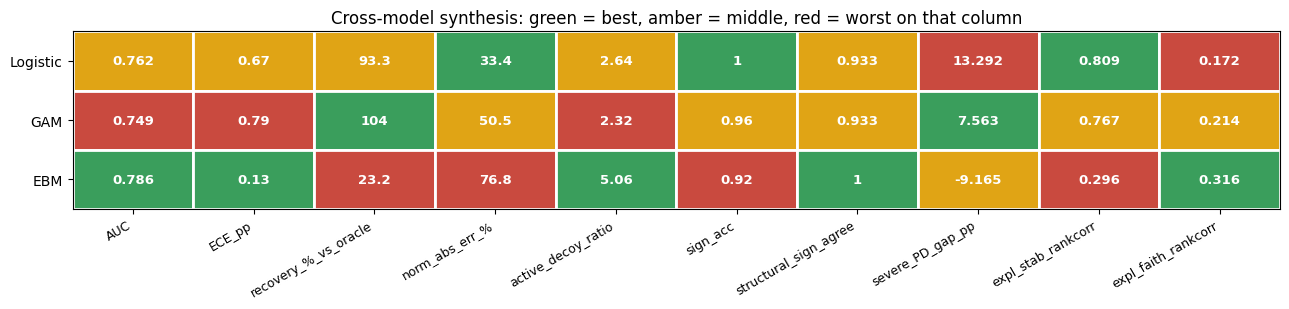

In [3]:
# Colour-coded version of the consolidated comparison above: same columns, same already-computed `summ`
# table, just re-rendered so the "no single model wins everywhere" finding is visible in one glance
# instead of requiring a column-by-column read of the table. No new data or computation here, this only
# reshapes and colours the `summ` DataFrame the cell above already built.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
metrics = list(summ.columns)
models = list(summ.index)

# Direction each column should be read in: higher-is-better columns are used as-is; columns where
# closer-to-a-target or closer-to-zero is best are transformed so "higher adjusted value = better"
# consistently, which is what the ranking and colouring below assumes.
def adjusted(col):
    v = summ[col].astype(float)
    if col in ('ECE_pp', 'norm_abs_err_%'): return -v          # lower is better
    if col == 'recovery_%_vs_oracle': return -(v - 100).abs()  # closer to 100 is better
    if col == 'severe_PD_gap_pp': return -v.abs()              # closer to 0 is better
    return v                                                   # higher is better

rank = pd.DataFrame({c: adjusted(c).rank(ascending=False, method='min') for c in metrics}, index=models)
# rank 1 = best on that column, 3 = worst. Mapped directly to a 3-step green/amber/red scale.
cmap = {1: '#3a9e5c', 2: '#e0a415', 3: '#c94a3f'}
fig, ax = plt.subplots(figsize=(1.2 * len(metrics) + 1, 3.2))
for i, m in enumerate(models):
    for j, c in enumerate(metrics):
        r = int(rank.loc[m, c])
        ax.add_patch(Rectangle((j, len(models) - 1 - i), 1, 1, facecolor=cmap[r], edgecolor='white', linewidth=2))
        ax.text(j + 0.5, len(models) - 1 - i + 0.5, f'{summ.loc[m, c]:g}', ha='center', va='center',
                fontsize=9.5, color='white', fontweight='bold')
ax.set_xlim(0, len(metrics)); ax.set_ylim(0, len(models))
ax.set_xticks(np.arange(len(metrics)) + 0.5); ax.set_xticklabels(metrics, rotation=30, ha='right', fontsize=9)
ax.set_yticks(np.arange(len(models)) + 0.5); ax.set_yticklabels(models[::-1], fontsize=10)
ax.set_title('Cross-model synthesis: green = best, amber = middle, red = worst on that column')
fig.tight_layout()
plt.show()

**Figure 5.2: cross-model synthesis, bar chart by metric.** The same ten metrics and the same already-computed `summ` table as Figure 5.1, shown here as one small bar chart per metric (each has its own scale, so a single shared axis would not work) with the exact value labelled on every bar. Panel titles use the full metric names. A complementary read to the colour matrix above, the colours show *ranking*, this shows *magnitude*.

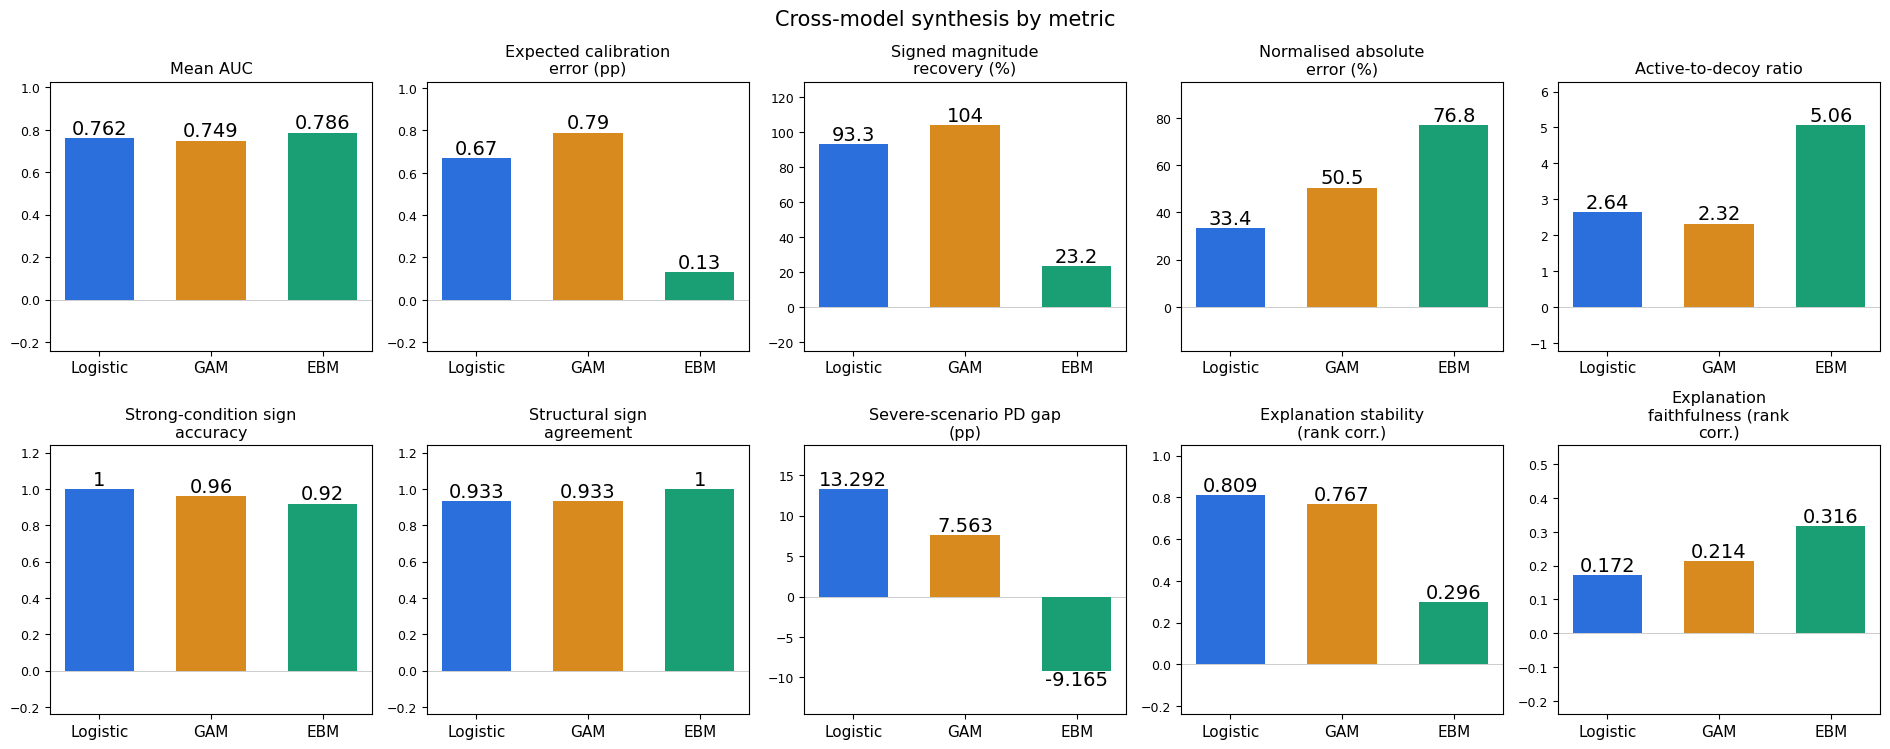

In [9]:
# A small-multiples bar chart version of the same summ table: one subplot per metric, since each metric
# has its own scale and a single shared axis would flatten most of them, three bars per subplot
# (Logistic/GAM/EBM), with the exact value labelled on top of every bar. Same already-computed `summ`
# table, no new data or computation. The grid sizes itself to the number of metrics. Panel titles use
# full, report-ready metric names and the value labels are enlarged so the figure reads cleanly in print.
import math, textwrap
CLRb = {'Logistic': '#2a6fdb', 'GAM': '#d98a1e', 'EBM': '#1a9e74'}
# Formal names for each metric (report-ready, no short forms), keyed by the summ column name.
LABELS = {
    'AUC': 'Mean AUC',
    'ECE_pp': 'Expected calibration error (pp)',
    'recovery_%_vs_oracle': 'Signed magnitude recovery (%)',
    'norm_abs_err_%': 'Normalised absolute error (%)',
    'active_decoy_ratio': 'Active-to-decoy ratio',
    'sign_acc': 'Strong-condition sign accuracy',
    'structural_sign_agree': 'Structural sign agreement',
    'severe_PD_gap_pp': 'Severe-scenario PD gap (pp)',
    'expl_stab_rankcorr': 'Explanation stability (rank corr.)',
    'expl_faith_rankcorr': 'Explanation faithfulness (rank corr.)',
}
metrics = list(summ.columns); models = list(summ.index)
ncols = 5; nrows = math.ceil(len(metrics) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.8 * nrows))
axflat = np.array(axes).reshape(-1)
for ax, col in zip(axflat, metrics):
    vals = summ[col].astype(float)
    bars = ax.bar(models, vals, color=[CLRb[m] for m in models], width=0.62)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{v:g}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=14)
    ax.axhline(0, color='#ccc', lw=0.7, zorder=0)
    # Full metric name, wrapped over up to two lines so long titles stay readable.
    ax.set_title(textwrap.fill(LABELS.get(col, col), 22), fontsize=11.5)
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=9)
    # Extra headroom so the enlarged value label never collides with the plot edge.
    lo, hi = vals.min(), vals.max()
    pad = max(abs(hi - lo), abs(hi), 1) * 0.24
    ax.set_ylim(min(0, lo) - pad, max(0, hi) + pad)
# Hide any unused axes in the last row.
for ax in axflat[len(metrics):]:
    ax.set_visible(False)
fig.suptitle('Cross-model synthesis by metric', fontsize=15)
fig.tight_layout()
plt.show()

In [5]:
# The recovery table and the predictive league, shown in full.
display(pd.DataFrame(S['planted_recovery']).T)
display(pd.DataFrame(S['predictive_league']).T)
# Explanation (interaction) stability under stress, per model (mean over severe / COVID / inflation).
es_summary = {m: {k: v for k, v in d.items() if k != 'per_regime'} for m, d in S['explanation_stability'].items()}
print('Explanation stability under stress (interaction fingerprint vs benign baseline):')
display(pd.DataFrame(es_summary).T)

,sign_acc,mean_b_active,mean_oracle_b_active,recovery_pct_vs_oracle,norm_abs_err_pct,mean_b_decoy,active_decoy_ratio,power_active,fpr_decoy
EBM|moderate,0.92,0.028,0.142,18.2,81.8,0.008,3.51,0.00,0.027
EBM|strong,0.92,0.059,0.252,23.2,76.8,0.012,5.06,0.32,0.087
EBM|weak,0.80,0.007,0.072,7.7,92.3,0.004,1.98,0.00,0.007
GAM|moderate,0.88,0.171,0.142,107.6,70.1,0.086,1.98,0.00,0.007
GAM|strong,0.96,0.274,0.252,104.0,50.5,0.118,2.32,0.12,0.020
GAM|weak,0.72,0.120,0.072,98.9,145.3,0.100,1.19,0.04,0.013
Logistic|moderate,0.92,0.147,0.142,98.9,49.7,0.070,2.10,0.00,0.007
Logistic|strong,1.00,0.235,0.252,93.3,33.4,0.089,2.64,0.00,0.000
Logistic|weak,0.76,0.109,0.072,86.9,113.0,0.077,1.41,0.00,0.007


,auc,brier,ece,cal_slope,avg_precision
EBM,0.7857,0.0081,0.0013,0.9712,0.0600
GAM,0.7491,0.0104,0.0079,0.4662,0.0344
Logistic,0.7622,0.0098,0.0067,0.5368,0.0373


Explanation stability under stress (interaction fingerprint vs benign baseline):


,mean_sign_preservation,mean_rank_corr,mean_abs_delta_bhat
Logistic,1.000,0.809,0.0291
GAM,0.963,0.767,0.0375
EBM,0.360,0.296,0.0238


### 5.3 Research answers and governance

In [6]:
# Print the three research question answers.
S = load_json(f'{OUT}/stage5_synthesis.json')
for k, v in S['rq_answers'].items(): print(f'{k}:\n  {v}\n')

RQ1_recovery:
  Direction is recoverable across LR, GAM and EBM (sign accuracy at least 0.88). Signed magnitude recovery versus the oracle own ruler measured b hat is near complete for LR (about 93 to 99 percent) and slightly above unity for GAM (about 104 to 107 percent, a mild over expression) but strongly attenuated for EBM (about 19 to 23 percent), which instead shows the cleanest active versus decoy separation. Structural unplanted interactions are recovered directionally, best by EBM.

RQ2_stability:
  Under real out of sample historical stress (COVID and inflation) all models transport with small PD gaps. Under out of support severe forward stress they diverge and fail in opposite directions: the smallest severe PD gap in absolute terms is GAM, but EBM under predicts while LR and GAM over predict, so this is not an unambiguous winner. The interpretability side tells the same story. Measuring each model interaction fingerprint under stress against the benign baseline, Logistic ke

In [7]:
# Governance position, claim boundary, and the reproducibility manifest.
print(json.dumps(S['governance'], indent=2))
print('\nReproducibility manifest:'); print(json.dumps(S['reproducibility_manifest'], indent=2, default=str))

{
  "transparency": "LR is fully transparent; GAM and EBM are interpretable through their shape functions and surfaces",
  "reproducibility": "seeds and configuration are sealed in the manifest, the oracle is exact, and the tuned settings are frozen",
  "claim_boundary": "this is methodological recovery inside a UK informed simulator, not causal or true UK or Lloyds coefficients"
}

Reproducibility manifest:
{
  "experiment_manifest": "experiment_manifest.json",
  "hidden_set_seed": 20240824,
  "run_config": {
    "pilot": false,
    "full": true,
    "seeds": [
      1,
      2,
      3,
      4,
      5
    ],
    "strengths": [
      "null",
      "weak",
      "moderate",
      "strong"
    ],
    "n_orig": 600,
    "n_null": 10,
    "dev_sub": 90000,
    "n_bg": 130,
    "floor_frac": 0.01,
    "tuned": {
      "LR": {
        "C": 0.3
      },
      "GAM": {
        "lam": 2.0,
        "n_splines": 5
      },
      "EBM": {
        "learning_rate": 0.01
      }
    },
    "gam_ba